In [81]:
import jlens
import json
import gzip
import pandas as pd

jlens.configure_logging()
MODEL_NAME = "Qwen/Qwen3.5-0.8B"
# MODEL_NAME = "Qwen/Qwen3.5-4B"
# MODEL_NAME = "Qwen/Qwen3.6-27B"

LENS_REPO = "neuronpedia/jacobian-lens"
LENS_REVISION = "qwen-n1000"
LENS_FILE = {
    "Qwen/Qwen3.5-4B": "qwen3.5-4b/jlens/Salesforce-wikitext/Qwen3.5-4B_jacobian_lens_n1000.pt",
    "Qwen/Qwen3.6-27B": "qwen3.6-27b/jlens/Salesforce-wikitext/Qwen3.6-27B_jacobian_lens_n1000.pt",
    "Qwen/Qwen3.5-0.8B": "qwen3.5-0.8b/jlens/Salesforce-wikitext/Qwen3.5-0.8B_jacobian_lens.pt"
}[MODEL_NAME]

In [82]:
import torch
import transformers

hf_model = transformers.AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, dtype=torch.bfloat16
).cuda()
tokenizer = transformers.AutoTokenizer.from_pretrained(MODEL_NAME)
model = jlens.from_hf(hf_model, tokenizer)
model

Loading weights: 100%|██████████| 320/320 [00:01<00:00, 230.56it/s]


HFLensModel(Qwen3_5ForCausalLM, n_layers=24, d_model=1024)

In [83]:
lens = jlens.JacobianLens.from_pretrained(
    LENS_REPO, filename=LENS_FILE, revision=LENS_REVISION
)
lens

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Fetching 1 files: 100%|██████████| 1/1 [00:00<00:00, 70.08it/s]


JacobianLens(d_model=1024, n_prompts=233, source_layers=[0..22] (23 layers))

Step 2: Apply J-Lens

In [84]:
with open('data/experiments/probe-swap.json', 'r') as file:
    data = json.load(file)['items']

print(len(data))
print(data)

#slice data
prompt_storage = []
for i in data:
  prompt_storage.append(i['prompt'])


90
[{'name': 'amazon-language', 'category': 'multihop', 'prompt': 'Fact: The language spoken in the country where the Amazon River ends is ', 'intermediate': 'Brazil', 'answer': 'Portuguese', 'swap_to': 'Mexico', 'swap_answer': 'Spanish'}, {'name': 'animal-cover-turtle', 'category': 'animal-cover', 'prompt': 'Fact: The hard covering on the back of the slow reptile that can pull its head inside its body is called a', 'intermediate': 'turtle', 'answer': 'shell', 'swap_to': 'snake', 'swap_answer': 'scale'}, {'name': 'animal-legs-buffalo2', 'category': 'animal-legs', 'prompt': 'Fact: The number of legs on the large horned animal that roamed the American plains in huge herds is', 'intermediate': 'buffalo', 'answer': 'four', 'swap_to': 'spider', 'swap_answer': 'eight'}, {'name': 'animal-nose-elephant', 'category': 'animal-nose', 'prompt': 'Fact: The long flexible body part that the largest land animal uses to pick things up is called a', 'intermediate': 'elephant', 'answer': 'trunk', 'swap_t

lens.apply 
    
    Args:
            model: The model to read out from.
            prompt: Input text.
            layers: Layers to read out at. Defaults to all of
                :attr:`source_layers`. Must be a subset of
                :attr:`source_layers` when ``use_jacobian`` is ``True``.
            positions: Token positions to read out (Python indexing into the
                sequence; negative indices count from the end). ``None`` returns
                every position.
            max_seq_len: Truncate the prompt to this many tokens.
            use_jacobian: If ``False``, skip the ``J_l`` transport (vanilla
                logit-lens baseline).       
       
    Returns:
            J-lens outputs
            A triple ``(lens_logits, model_logits, input_ids)``. ``lens_logits``
            maps each requested layer to a ``[n_positions, vocab_size]`` tensor;

            Residual Stream outputs
            ``model_logits`` is the model's actual final-layer logits at the
            same positions (same shape). ``n_positions`` is ``len(positions)``,
            or the full sequence length when ``positions`` is ``None``.


In [85]:
from jlens.vis import _meaningful_token_mask, _ranks_of

single_prompt = data[0]["prompt"]
jlens_logits, model_logits, input_ids = lens.apply(model, single_prompt, layers=lens.source_layers, positions = None)
#print(len(model_logits), len(model_logits[0]))
#print(model_logits.shape)
#(token_len (position), vocab size)
position = model_logits.shape[0]
vocab_size = model_logits.shape[1]
mask = _meaningful_token_mask(tokenizer, vocab_size, model_logits.device)
labels = [tokenizer.decode([t]) for t in input_ids[0][:position]]

#true logits
jlens_logits[model.n_layers - 1] = model_logits

tokens, ranks = {}, {}
for layer, logits in sorted(jlens_logits.items()):
  #layer = layer_idx, logits = [n_positions, vocab_size]
  top_idx = logits.masked_fill(~mask, float("-inf")).topk(1, dim=-1).indices # [n_positions, 1]
  tokens[layer] = [tokenizer.decode([t]) for t in top_idx.squeeze(-1).tolist()]
  ranks[layer] = _ranks_of(logits, top_idx).squeeze(-1).tolist()
  
token_df = pd.DataFrame(tokens, index=labels).T
rank_df = pd.DataFrame(ranks, index=labels).T

token_df.head()

,Fact,:,The,language,spoken,in,the,country,where,the,Amazon,River,ends,is,
0,Fact,colon,e,language,spoken,place,Americans,Country,where,e,Amazon,River,Ends,being,sea
1,Fact,flu,Crown,language,spoken,place,south,country,where,man,Amazon,River,Ends,being,sea
2,Fact,黄花,Forest,language,spoken,place,place,country,where,people,Amazon,River,ending,being,sea
3,Fact,NYT,Forest,language,spoken,place,families,country,where,people,Amazon,River,ending,being,sea
4,Fact,NYT,Crown,language,spoken,Iraq,Iraq,country,where,people,Amazon,River,ends,being,sea


Step 3: Run on Experiment Prompts

In [ ]:
from jlens.examples import resolve_prompt
from jlens.vis import build_page, compute_slice, notebook_iframe

gloss = {
    int(k): v for k, v in json.load(gzip.open("assets/qwen_gloss.json.gz")).items()
}

output = []

for idx, prompt in enumerate(prompt_storage):
    slice_data = compute_slice(
        model,
        lens,
        prompt,
        layer_stride=1,
        mask_display=True,
    )
    
    #top_ranks: [token_len (position), layer, top_n_tokens/ranks]    
    #top_ranks/top_ids: [seq_len, n_layers, top_n]

    for position in range(slice_data.top_ranks.shape[0]):
        for layer_idx, layer in enumerate(slice_data.layers):
             output.append({'prompt_idx': idx,
                 'prompt_name' : data[idx]['name'],
                 'prompt' : prompt,
                 "layer": layer,
                 "position": position,
                 "top1_token" : tokenizer.decode([slice_data.top_ids[position, layer_idx, 0]]),
                 #"top5_token" : [tokenizer.decode([t]) for t in slice_data.top_ids[position, layer_idx, :5]],
                 "top10_tokens" : [tokenizer.decode([t]) for t in slice_data.top_ids[position, layer_idx, :]],
                 "top_rank": int(slice_data.top_ranks[position, layer_idx, 0]),
                 #"top5_rank": int(slice_data.top_ranks[position, layer_idx, :5]),
                 "top10_ranks": slice_data.top_ranks[position, layer_idx, :]
             })

print(len(output))
output_df = pd.DataFrame(output)
output_df.head()

In [ ]:
#rank is how high up the guess/token is wrt its vocab
#id is the token itself
import numpy as np

final_layer = output_df["layer"].max()
final_tokens = output_df[output_df.layer == final_layer].set_index(["prompt_idx", "position"])["top1_token"]


output_df["final_token"] = output_df.set_index(["prompt_idx", "position"]).index.map(final_tokens)
output_df["pass@1_matches_final"] = output_df["top1_token"].str.strip() == output_df["final_token"].str.strip()

output_df['pass@10_matches_final'] = output_df.apply(
    lambda row: (np.array([t.strip() for t in row['top10_tokens']]) == row["final_token"].strip()).any(), axis = 1
)

summary = output_df.groupby("layer").agg(
    mean_rank=("top_rank", "mean"),
    pass_at_1=("pass@1_matches_final", "mean"),
    pass_at_10 = ("pass@10_matches_final", "mean")
).reset_index()

summary

,layer,mean_rank,pass_at_1,pass_at_10
0,0,5.280749,0.010027,0.047460
1,1,3.385695,0.009358,0.064171
2,2,1.560829,0.011364,0.116979
3,3,4.082219,0.008690,0.070187
4,4,2.471257,0.010027,0.088235
5,5,1.479278,0.015374,0.063503
6,6,0.836898,0.008690,0.106952
7,7,0.601604,0.007353,0.059492
8,8,0.620989,0.007353,0.060829
9,9,0.917781,0.008690,0.064171


KeyError: 'layer'

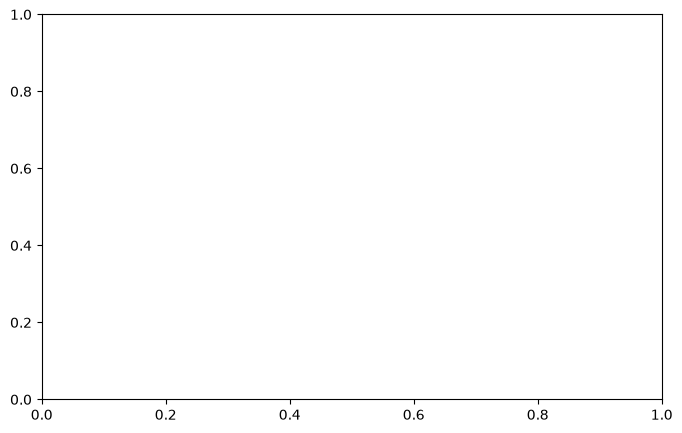

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(summary["layer"], summary["pass_at_1"], marker="o", label="pass@1")
ax.plot(summary["layer"], summary["pass_at_10"], marker="o", label="pass@10")

ax.set_xlabel("layer")
ax.set_ylabel("rate")
ax.set_title("J-lens: pass@1 vs pass@10 by layer")
ax.legend()

fig.tight_layout()
plt.show()